In [ ]:
import pandas as pd

df = pd.read_csv('/content/Retail_Sales_Performance_Cleaned.csv')

df.head()

,Order_ID,Order_Date,Region,State,Store,Product_Category,Product_Name,Customer_Segment,Sales,Quantity,Discount,Profit,Shipping_Mode
0,R1001,2025-01-05,South,Karnataka,Store D,Electronics,Keyboard,Home Office,51153,11,10,5115.0,Same Day
1,R1002,2025-01-09,West,Gujarat,Store C,Furniture,Bookshelf,Consumer,33245,17,15,2493.0,Same Day
2,R1003,2025-01-13,East,Assam,Store B,Furniture,Chair,Consumer,57582,3,10,5758.0,Standard
3,R1004,2025-01-17,South,Tamil Nadu,Store E,Furniture,Chair,Home Office,50489,9,0,7573.0,Same Day
4,R1005,2025-01-21,East,Odisha,Store F,Electronics,Speaker,Consumer,48467,6,8,5331.0,Express


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          47 non-null     object 
 1   Order_Date        47 non-null     object 
 2   Region            47 non-null     object 
 3   State             47 non-null     object 
 4   Store             47 non-null     object 
 5   Product_Category  47 non-null     object 
 6   Product_Name      47 non-null     object 
 7   Customer_Segment  47 non-null     object 
 8   Sales             47 non-null     int64  
 9   Quantity          47 non-null     int64  
 10  Discount          47 non-null     int64  
 11  Profit            47 non-null     float64
 12  Shipping_Mode     47 non-null     object 
dtypes: float64(1), int64(3), object(9)
memory usage: 4.9+ KB


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          47 non-null     object        
 1   Order_Date        47 non-null     datetime64[ns]
 2   Region            47 non-null     object        
 3   State             47 non-null     object        
 4   Store             47 non-null     object        
 5   Product_Category  47 non-null     object        
 6   Product_Name      47 non-null     object        
 7   Customer_Segment  47 non-null     object        
 8   Sales             47 non-null     int64         
 9   Quantity          47 non-null     int64         
 10  Discount          47 non-null     int64         
 11  Profit            47 non-null     float64       
 12  Shipping_Mode     47 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(8)
memory usage: 4.9+ KB


overview of data

In [ ]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,47.000000,47.000000,47.000000,47.000000
mean,41500.893617,9.723404,7.191489,4676.829787
std,20439.959410,5.713075,5.123001,2535.875008
min,2041.000000,1.000000,0.000000,306.000000
25%,24328.000000,5.000000,2.000000,2523.500000
50%,48369.000000,8.000000,8.000000,4961.000000
75%,58086.000000,15.500000,11.000000,6773.000000
max,69637.000000,20.000000,15.000000,9664.000000


Regional performance

In [ ]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Orders=('Order_ID', 'count')
).sort_values('Total_Sales', ascending=False)

region_summary

,Total_Sales,Total_Profit,Total_Quantity,Orders
Region,,,,
West,692131,77340.0,155,16
South,504167,55348.0,83,10
East,419263,49682.0,144,12
North,334981,37441.0,75,9


Why is South generating higher sales with fewer units?

In [ ]:
region_summary['Average_Order_Value'] = (region_summary['Total_Sales'] / region_summary['Orders'])

region_summary['Profit_Margin_%'] = (
    region_summary['Total_Profit'] / region_summary['Total_Sales'] * 100)

region_summary.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders,Average_Order_Value,Profit_Margin_%
Region,,,,,,
West,692131,77340.0,155,16,43258.19,11.17
South,504167,55348.0,83,10,50416.70,10.98
East,419263,49682.0,144,12,34938.58,11.85
North,334981,37441.0,75,9,37220.11,11.18


"**West** generated the highest total sales, supported by the **highest number of orders**. **South** recorded the **highest average order** value despite having fewer orders, while **East** achieved the **highest profit margin**. This indicates that regional performance differs not only by sales volume but also by order value and profitability."

Product Category Performance

In [ ]:
category_summary = df.groupby('Product_Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Orders=('Order_ID', 'count')
)

category_summary['Average_Order_Value'] = (
    category_summary['Total_Sales'] / category_summary['Orders']
)

category_summary['Profit_Margin_%'] = (
    category_summary['Total_Profit'] /
    category_summary['Total_Sales'] * 100
)

category_summary.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders,Average_Order_Value,Profit_Margin_%
Product_Category,,,,,,
Electronics,559823,57737.0,126,13,43063.31,10.31
Furniture,635782,70606.0,126,15,42385.47,11.11
Office Supplies,754937,91468.0,205,19,39733.53,12.12


In [ ]:
product_summary = df.groupby('Product_Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Orders=('Order_ID', 'count')
)

product_summary['Profit_Margin_%'] = (
    product_summary['Total_Profit'] /
    product_summary['Total_Sales'] * 100
)

product_summary.sort_values('Total_Sales', ascending=False).round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders,Profit_Margin_%
Product_Name,,,,,
Markers,186995,23178.0,58,5,12.39
Speaker,181754,18765.0,41,3,10.32
Keyboard,170341,15321.0,23,4,8.99
Pen Set,166202,16792.0,27,3,10.10
Cabinet,152538,17077.0,25,3,11.20
Paper,150865,20550.0,40,3,13.62
Table,143055,12950.0,32,3,9.05
Files,134543,14731.0,22,3,10.95
Bookshelf,132157,15524.0,28,3,11.75


In [ ]:
discount_analysis = df.groupby('Discount').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
)

discount_analysis['Profit_Margin_%'] = (
    discount_analysis['Total_Profit'] /
    discount_analysis['Total_Sales'] * 100
)

discount_analysis.round(2)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
Discount,,,,
0,310604,46586.0,9,15.0
2,192919,27004.0,6,14.0
5,290003,36248.0,5,12.5
8,219104,24099.0,4,11.0
10,498632,49858.0,11,10.0
12,205086,18454.0,7,9.0
15,234194,17562.0,5,7.5


"The analysis shows an inverse relationship between discount level and profit margin. Higher discount levels are associated with progressively lower profit margins in the cleaned dataset."

In [ ]:
segment_summary = df.groupby('Customer_Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Orders=('Order_ID', 'count')
)

segment_summary['Average_Order_Value'] = (
    segment_summary['Total_Sales'] /
    segment_summary['Orders']
)

segment_summary['Profit_Margin_%'] = (
    segment_summary['Total_Profit'] /
    segment_summary['Total_Sales'] * 100
)

segment_summary.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders,Average_Order_Value,Profit_Margin_%
Customer_Segment,,,,,,
Consumer,919106,96008.0,206,20,45955.30,10.45
Corporate,567298,66656.0,140,15,37819.87,11.75
Home Office,464138,57147.0,111,12,38678.17,12.31


Consumer customers generated the highest sales and order volume, while Home Office recorded the highest profit margin. This indicates that sales contribution and profitability vary across customer segments."

In [ ]:
segment_discount = df.groupby(
    ['Customer_Segment', 'Discount']
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
)

segment_discount['Profit_Margin_%'] = (
    segment_discount['Total_Profit'] /
    segment_discount['Total_Sales'] * 100
)

segment_discount.round(2)

Total_Sales  Total_Profit  Orders  Profit_Margin_%
Customer_Segment Discount                                                    
Consumer         0               80935       12139.0       2            15.00
                 2              112926       15808.0       2            14.00
                 5               54348        6793.0       1            12.50
                 8              110259       12128.0       2            11.00
                 10             220228       22020.0       5            10.00
                 12             106216        9558.0       3             9.00
                 15             234194       17562.0       5             7.50
Corporate        0              138686       20801.0       4            15.00
                 2                7307        1022.0       1            13.99
                 5               97248       12155.0       2            12.50
                 8              108845       11971.0       2            11.00
                 10             134179       13416.0       3            10.00
                 12              81033        7291.0       3             9.00
Home Office      0               90983       13646.0       3            15.00
                 2               72686       10174.0       3            14.00
                 5              138407       17300.0       2            12.50
                 10             144225       14422.0       3            10.00
                 12              17837        1605.0       1             9.00

Consumer generated the highest sales and order volume but recorded the lowest overall profit margin. The segment-level discount analysis indicates that Consumer sales include a larger share of transactions at higher discount levels, which is associated with lower margins."

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_summary = df.groupby('Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
)

monthly_summary['Profit_Margin_%'] = (
    monthly_summary['Total_Profit'] /
    monthly_summary['Total_Sales'] * 100
)

monthly_summary.round(2)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%
Month,,,,
2025-01,333551,36099.0,7,10.82
2025-02,239605,29533.0,6,12.33
2025-03,273266,27887.0,8,10.21
2025-04,203619,20061.0,7,9.85
2025-05,421487,50847.0,8,12.06
2025-06,303878,37147.0,8,12.22
2025-07,175136,18237.0,3,10.41


"July recorded the lowest sales and profit in the analyzed period, coinciding with the lowest number of orders. Further drill-down is required to determine whether the decline was driven by lower order volume, order value, or product/region mix."

In [ ]:
monthly_summary['Average_Order_Value'] = (
    monthly_summary['Total_Sales'] /
    monthly_summary['Orders']
)

monthly_summary.round(2)

,Total_Sales,Total_Profit,Orders,Profit_Margin_%,Average_Order_Value
Month,,,,,
2025-01,333551,36099.0,7,10.82,47650.14
2025-02,239605,29533.0,6,12.33,39934.17
2025-03,273266,27887.0,8,10.21,34158.25
2025-04,203619,20061.0,7,9.85,29088.43
2025-05,421487,50847.0,8,12.06,52685.88
2025-06,303878,37147.0,8,12.22,37984.75
2025-07,175136,18237.0,3,10.41,58378.67


In [ ]:
# Shipping Mode Analysis

shipping_summary = df.groupby('Shipping_Mode').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Orders=('Order_ID', 'count')
)

# Calculate business metrics
shipping_summary['Average_Order_Value'] = (
    shipping_summary['Total_Sales'] / shipping_summary['Orders']
)

shipping_summary['Profit_Margin_%'] = (
    shipping_summary['Total_Profit'] / shipping_summary['Total_Sales'] * 100
)

# Sort by total sales
shipping_summary = shipping_summary.sort_values(
    'Total_Sales',
    ascending=False
)

shipping_summary.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Orders,Average_Order_Value,Profit_Margin_%
Shipping_Mode,,,,,,
Same Day,831236,93494.0,209,20,41561.80,11.25
Standard,678371,76966.0,145,15,45224.73,11.35
Express,440935,49351.0,103,12,36744.58,11.19


Shipping modes showed only minor variation in profitability, with profit margins remaining close across Same Day, Standard, and Express deliveries. Sales differences appear to be more related to order volume than shipping mode.

In [ ]:
# Final Correlation Analysis

correlation_data = df[['Sales', 'Quantity', 'Discount', 'Profit']]

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,Sales,Quantity,Discount,Profit
Sales,1.00,0.08,0.11,0.90
Quantity,0.08,1.00,-0.05,0.12
Discount,0.11,-0.05,1.00,-0.28
Profit,0.90,0.12,-0.28,1.00


In [ ]:
# Export final cleaned dataset for Power BI

df.to_csv(
    '/content/Retail_Sales_Performance_Final.csv',
    index=False
)

print("Final dataset exported successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Final dataset exported successfully.
Rows: 47
Columns: 14


In [ ]:
# Export clean dataset for Power BI

powerbi_df = df[
    [
        'Order_ID',
        'Order_Date',
        'Region',
        'State',
        'Store',
        'Product_Category',
        'Product_Name',
        'Customer_Segment',
        'Sales',
        'Quantity',
        'Discount',
        'Profit',
        'Shipping_Mode'
    ]
]

powerbi_df.to_csv(
    '/content/Retail_Sales_Performance_Final.csv',
    index=False
)

print("Power BI dataset exported successfully.")
print("Rows:", len(powerbi_df))
print("Columns:", len(powerbi_df.columns))

Power BI dataset exported successfully.
Rows: 47
Columns: 13


Dataset Loaded Successfully

First 5 Rows:


,Order_ID,Order_Date,Region,State,Store,Product_Category,Product_Name,Customer_Segment,Sales,Quantity,Discount,Profit,Shipping_Mode
0,R1001,2025-01-05,South,Karnataka,Store D,Electronics,Keyboard,Home Office,51153,11,10,5115.0,Same Day
1,R1002,2025-01-09,West,Gujarat,Store C,Furniture,Bookshelf,Consumer,33245,17,15,2493.0,Same Day
2,R1003,2025-01-13,East,Assam,Store B,Furniture,Chair,Consumer,57582,3,10,5758.0,Standard
3,R1004,2025-01-17,South,Tamil Nadu,Store E,Furniture,Chair,Home Office,50489,9,0,7573.0,Same Day
4,R1005,2025-01-21,East,Odisha,Store F,Electronics,Speaker,Consumer,48467,6,8,5331.0,Express



Dataset Shape: (47, 13)

Column Names:
['Order_ID', 'Order_Date', 'Region', 'State', 'Store', 'Product_Category', 'Product_Name', 'Customer_Segment', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Mode']

Data preparation completed.

Monthly Sales Data:


,Month,Sales,Month_Label,Time_Index
0,2025-01,333551,2025-01,1
1,2025-02,239605,2025-02,2
2,2025-03,273266,2025-03,3
3,2025-04,203619,2025-04,4
4,2025-05,421487,2025-05,5
5,2025-06,303878,2025-06,6
6,2025-07,175136,2025-07,7


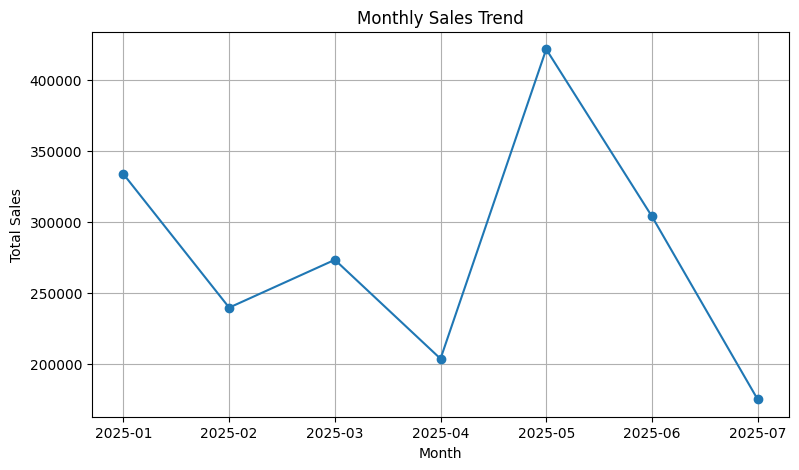


Training Data:


,Month,Sales,Month_Label,Time_Index
0,2025-01,333551,2025-01,1
1,2025-02,239605,2025-02,2
2,2025-03,273266,2025-03,3
3,2025-04,203619,2025-04,4
4,2025-05,421487,2025-05,5



Testing Data:


,Month,Sales,Month_Label,Time_Index
5,2025-06,303878,2025-06,6
6,2025-07,175136,2025-07,7



Linear Regression Model Trained Successfully
Intercept: 252339.8
Coefficient: 13988.599999999999

Actual vs Predicted Sales:


,Month,Actual_Sales,Predicted_Sales
0,2025-06,303878,336271.4
1,2025-07,175136,350260.0



LINEAR REGRESSION MODEL EVALUATION
R² Score : -2.827
MAE      : ₹103,758.70
RMSE     : ₹125,932.02


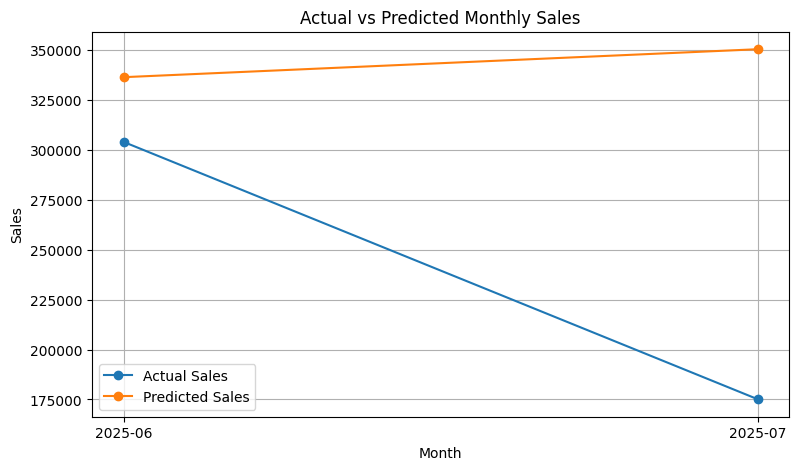


NEXT MONTH SALES PREDICTION
Experimental Predicted Sales for Next Month: ₹364,248.60

MODEL INTERPRETATION:
The negative R² score indicates that the model does not predict the held-out monthly sales well.

Important Limitation: Only a small number of monthly observations are available. Therefore, the next-month prediction should be treated as experimental rather than a reliable business forecast.


In [ ]:
# ============================================================
# LINEAR REGRESSION MODEL - MONTHLY SALES PREDICTION
# Retail Sales Performance Analysis
# ============================================================

# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ============================================================
# 2. LOAD CLEANED DATASET
# ============================================================

# IMPORTANT:
# Replace the file name below with your actual cleaned CSV file name.

df = pd.read_csv('/content/Retail_Sales_Performance_Cleaned.csv')

print("Dataset Loaded Successfully")
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

print("\nColumn Names:")
print(df.columns.tolist())

# Convert Sales to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

# Remove rows with missing Order_Date or Sales
df = df.dropna(subset=['Order_Date', 'Sales'])

print("\nData preparation completed.")


# ============================================================
# 4. CREATE MONTHLY SALES DATA
# ============================================================

df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month', as_index=False)['Sales']
      .sum()
)

# Convert Month to string for display
monthly_sales['Month_Label'] = monthly_sales['Month'].astype(str)

# Create time index
monthly_sales['Time_Index'] = np.arange(
    1,
    len(monthly_sales) + 1
)

print("\nMonthly Sales Data:")
display(monthly_sales)


# ============================================================
# 5. VISUALIZE MONTHLY SALES
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_sales['Month_Label'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

# We have only 7 months of data.
# Therefore:
# Jan-May = Training
# Jun-Jul = Testing

train = monthly_sales.iloc[:5].copy()
test = monthly_sales.iloc[5:].copy()

X_train = train[['Time_Index']]
y_train = train['Sales']

X_test = test[['Time_Index']]
y_test = test['Sales']

print("\nTraining Data:")
display(train)

print("\nTesting Data:")
display(test)


# ============================================================
# 7. CREATE AND TRAIN LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nLinear Regression Model Trained Successfully")

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])


# ============================================================
# 8. MAKE PREDICTIONS ON TEST DATA
# ============================================================

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Month': test['Month_Label'].values,
    'Actual_Sales': y_test.values,
    'Predicted_Sales': y_pred
})

print("\nActual vs Predicted Sales:")
display(comparison)


# ============================================================
# 9. MODEL ACCURACY / EVALUATION
# ============================================================

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("\n======================================")
print("LINEAR REGRESSION MODEL EVALUATION")
print("======================================")

print(f"R² Score : {r2:.3f}")
print(f"MAE      : ₹{mae:,.2f}")
print(f"RMSE     : ₹{rmse:,.2f}")

print("======================================")


# ============================================================
# 10. ACTUAL VS PREDICTED CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    comparison['Month'],
    comparison['Actual_Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    comparison['Month'],
    comparison['Predicted_Sales'],
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 11. PREDICT NEXT MONTH SALES
# ============================================================

next_time_index = len(monthly_sales) + 1

next_month_data = pd.DataFrame({
    'Time_Index': [next_time_index]
})

next_month_prediction = model.predict(
    next_month_data
)[0]

print("\n======================================")
print("NEXT MONTH SALES PREDICTION")
print("======================================")

print(
    f"Experimental Predicted Sales for Next Month: "
    f"₹{next_month_prediction:,.2f}"
)

print("======================================")


# ============================================================
# 12. AUTOMATIC MODEL INTERPRETATION
# ============================================================

print("\nMODEL INTERPRETATION:")

if r2 >= 0.75:
    print(
        "The model explains a relatively high proportion "
        "of the variation in the test data."
    )

elif r2 >= 0:
    print(
        "The model has limited predictive performance "
        "on the test data."
    )

else:
    print(
        "The negative R² score indicates that the model "
        "does not predict the held-out monthly sales well."
    )

print(
    "\nImportant Limitation: Only a small number of monthly "
    "observations are available. Therefore, the next-month "
    "prediction should be treated as experimental rather "
    "than a reliable business forecast."
)